
## TECHIN513:  Lab 1 - Elementary Music Synthesis

**Team Members**: Yuwen Chen, Yunxiao Du

**Overview**

The purpose of this lab is to familiarize you with constructing and processing discrete-time audio signals. You will review how to synthesize music notes and play them. You will concatenate a series of music notes into a small music piece, add volume variation to the music piece, overlap the adjacent notes to further make the music smoother and more realistic.

Through this process, you will learn to perform the following sound synthesis tasks:
- Generating musical notes
- Improving the quality of the generated sound
- Overlapping notes

In [53]:
import numpy as np
import IPython.display as ipd
# Usage:
# ipd.Audio(audio_array, rate=sampling_rate, autoplay=True)
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.io import wavfile as wav

In [54]:
# SimpleAudio constants.
DEFAULT_SAMPLE_RATE = 8000
DEFAULT_AMPLITUDE = 1
DEFAULT_BYTES_PER_SAMPLE = 2
DEFAULT_NUM_CHANNELS = 1

# Musical note frequencies.
A = 220.0
B = A * 2 ** (2 / 12)
C = A * 2 ** (3 / 12)
D = A * 2 ** (5 / 12)
E = A * 2 ** (7 / 12)
F = A * 2 ** (8 / 12)
G = A * 2 ** (10 / 12)

In [55]:
def play(data, num_channels=DEFAULT_NUM_CHANNELS, bytes_per_sample=DEFAULT_BYTES_PER_SAMPLE,
         sample_rate=DEFAULT_SAMPLE_RATE):
    """Returns a playable audio object

    Args:
        data: The audio data to be played (as a NumPy array).
        num_channels: The number of audio channels.
        bytes_per_sample: The number of bytes per sample per channel.
        sample_rate: The sample rate.
    """
    return ipd.Audio(data, rate=sample_rate, autoplay=True)
    

def display_envelope(signal, duration=-1, sample_rate=DEFAULT_SAMPLE_RATE, bytes_per_sample=DEFAULT_BYTES_PER_SAMPLE):

    """
    Plots the envelope of a duration of the generated audio. 

    Args:
        signal: The audio signal to be displayed (as a NumPy array).
        duration: The length of hte signal to be displayed. -1 to display entire signal.
        num_channels: The number of audio channels.
        bytes_per_sample: The number of bytes per sample per channel.
        sample_rate: The sample rate.
    """
    
    if duration < 0:
        duration = len(signal)/sample_rate
    
    n = int(duration*sample_rate)
    
    analytic_signal = hilbert(signal[0:n])
    amplitude_envelope = np.abs(analytic_signal)
        
    t = np.linspace(0,duration,len(amplitude_envelope))
    
    plt.figure()    
    plt.plot(t,amplitude_envelope)
    plt.show()

## Task 1: Generating Musical Notes

In [56]:
# defining note function 
def note(frequency, duration, amplitude=DEFAULT_AMPLITUDE, sample_rate=DEFAULT_SAMPLE_RATE):
    """Generates samples of a musical note.

    Samples are generated according to following equation:

        y(t) = A sin(wt)

    Args:
        frequency: The frequency of the note.
        duration: The length of the note in seconds.
        amplitude: The amplitude of the note.
        sample_rate: The sample rate.

    Returns:
        An array of samples representing the note.
    """
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    # Generate sinusoidal wave: y(t) = A * sin(2 * pi * f * t)
    return amplitude * np.sin(2 * np.pi * frequency * t)

In [71]:
# Use your function to generate the musical score for the Scarborough Fair.
quarter = 4000 / DEFAULT_SAMPLE_RATE
half = 2 * quarter                    
whole = 4 * quarter

rest_duration = 0.05
rest = np.zeros(int(rest_duration * DEFAULT_SAMPLE_RATE))

score = [
    (A, half),      # A half
    (A, quarter),   # A quarter
    (E, quarter),   # E quarter
    (E, quarter),   # E quarter
    (E, quarter),   # E quarter
    (B, quarter),   # B quarter
    (C, quarter),   # C quarter
    (B, quarter),   # B quarter
    (A, whole),     # A whole
]

notes = [np.concatenate([note(freq, dur), rest]) for (freq, dur) in score]
song = np.concatenate(notes)

# Play the audio sample
play(song)

### How would you incorporate the results using this syntax?

The list comprehension loops through each (frequency, duration) pair in the `score` list. For each pair, it generates a note using `note(freq, dur)` and adds a short rest after it with `np.concatenate()`. All notes are collected into a list, then `np.concatenate(notes)` joins them into a single audio array that can be played.

## Task 2: Time Scaling and Time Shifting Audio Signals

In [59]:
ipd.Audio('train32.wav')

Sampling rate: 32000Hz


Text(0.5, 0, 'Time Index')

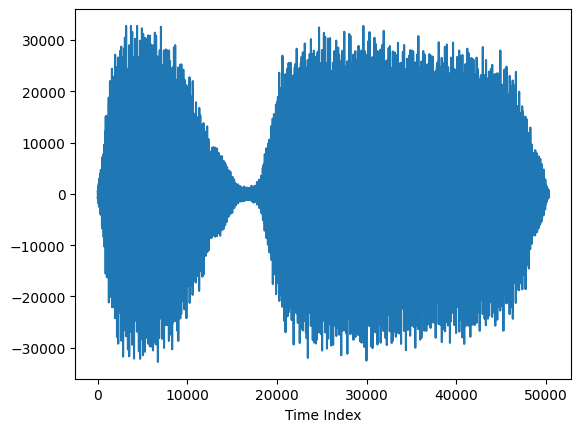

In [60]:
fs1, w = wav.read('train32.wav')                      # Load audio file
print('Sampling rate: ' + str(fs1) + 'Hz')                # Extract sampling frequency

plt.figure()    
_ = plt.plot(np.arange(np.size(w)), w)
plt.xlabel("Time Index")


In [61]:
# your code of task 2 goes below

def time_scale(signal, a, fs):
    """
    Perform time scaling on an audio waveform.

    Args:
        signal (numpy array): Input numpy array.
        a (float): Time scaling factor.
        fs (int): Sampling frequency (used to handle time shift in seconds if needed).
    
    Returns:
        numpy array: Transformed waveform.
    """
    n = np.arange(len(signal))  # Original time indices
    
    if a > 1:  # signal compression: w[n] = x[a*n]
        new_indices = np.arange(0, len(signal), a).astype(int)
        transformed_signal = signal[new_indices]
    elif a < 1 and a > 0:  # signal expansion: v[n] = x[n*a]
        new_length = int(len(signal) / a)
        new_indices = np.arange(new_length) * a
        transformed_signal = np.interp(new_indices, n, signal)
    elif a == 1:
        transformed_signal = signal
    else:
        print("Invalid choice of a")
        transformed_signal = signal

    return transformed_signal

Saved: w_compressed.wav, v_expanded.wav, z_reversed.wav


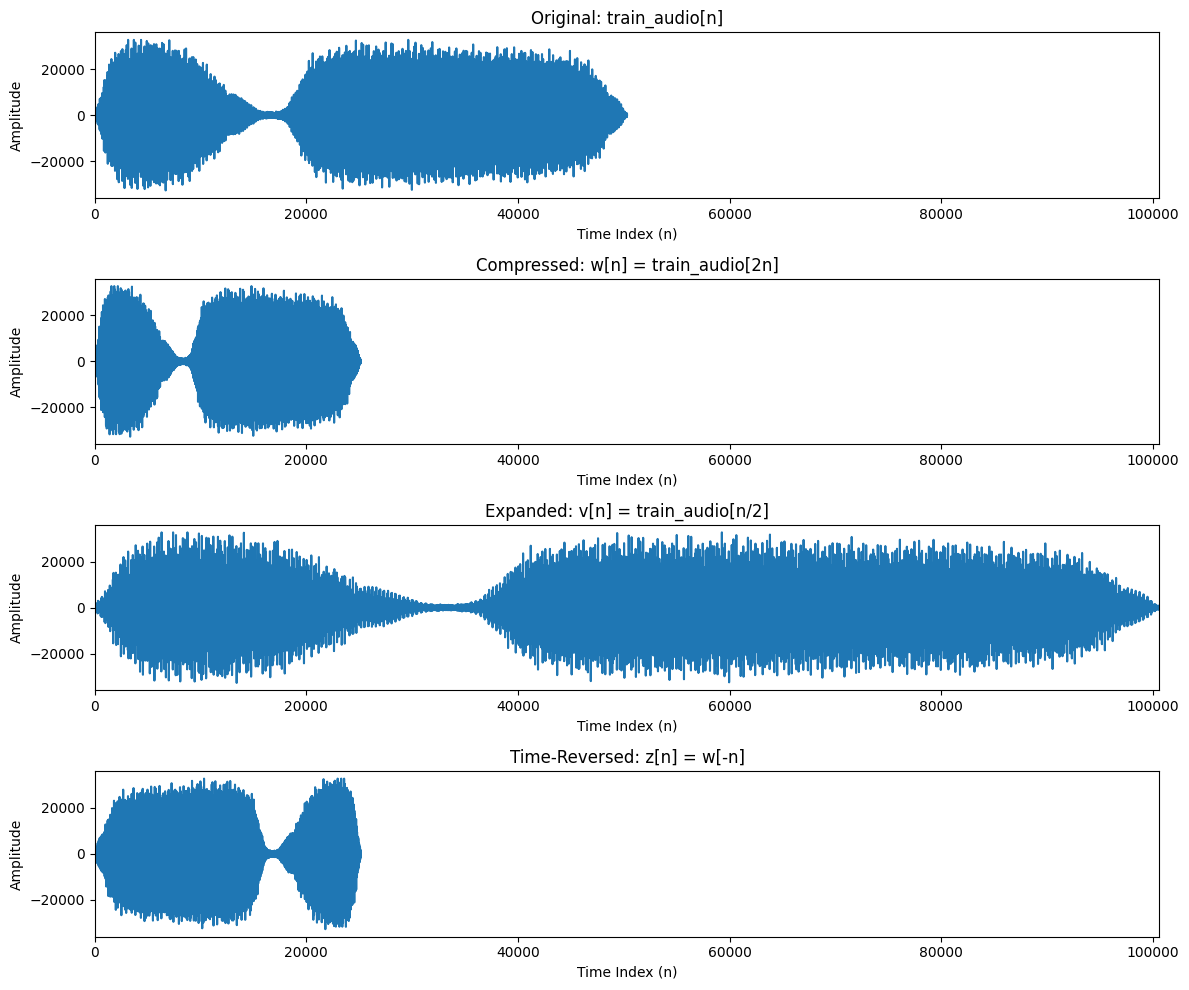


Play original signal:



Play compressed signal (w):



Play expanded signal (v):



Play time-reversed signal (z):


In [72]:
# Time Scaling

fs1, train_audio = wav.read('train32.wav')

# w[n] = train_audio[2n]
w = time_scale(train_audio, 2, fs1)

# v[n] = train_audio[n/2]
v = time_scale(train_audio, 0.5, fs1)

# z[n] = w[-n]
z = w[::-1]

wav.write('w_compressed.wav', fs1, w.astype(np.int16))
wav.write('v_expanded.wav', fs1, v.astype(np.int16))
wav.write('z_reversed.wav', fs1, z.astype(np.int16))

print("Saved: w_compressed.wav, v_expanded.wav, z_reversed.wav")

# Visualize
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

max_len = max(len(train_audio), len(w), len(v), len(z))

# Original signal
axes[0].plot(np.arange(len(train_audio)), train_audio)
axes[0].set_title('Original: train_audio[n]')
axes[0].set_xlabel('Time Index (n)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim([0, max_len])

# w[n] = train_audio[2n]
axes[1].plot(np.arange(len(w)), w)
axes[1].set_title('Compressed: w[n] = train_audio[2n]')
axes[1].set_xlabel('Time Index (n)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlim([0, max_len])

# v[n] = train_audio[n/2]
axes[2].plot(np.arange(len(v)), v)
axes[2].set_title('Expanded: v[n] = train_audio[n/2]')
axes[2].set_xlabel('Time Index (n)')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlim([0, max_len])

# z[n] = w[-n]
axes[3].plot(np.arange(len(z)), z)
axes[3].set_title('Time-Reversed: z[n] = w[-n]')
axes[3].set_xlabel('Time Index (n)')
axes[3].set_ylabel('Amplitude')
axes[3].set_xlim([0, max_len])

plt.tight_layout()
plt.show()

print("\nPlay original signal:")
ipd.display(ipd.Audio(train_audio, rate=fs1))
print("\nPlay compressed signal (w):")
ipd.display(ipd.Audio(w, rate=fs1))
print("\nPlay expanded signal (v):")
ipd.display(ipd.Audio(v, rate=fs1))
print("\nPlay time-reversed signal (z):")
ipd.display(ipd.Audio(z, rate=fs1))

In [63]:

def time_shift(signal, b):
    """
    Perform time shifting on a signal.

    Args:
        signal (numpy array): Input numpy array.
        b (int): Time shifting factor.
        fs (int): Sampling frequency (used to handle time shift in seconds if needed).
    
    Returns:
        numpy array: Transformed waveform.
    """

    # Check if `b` is a valid integer
    if not isinstance(b, int):
        raise ValueError("Invalid choice of b.")
    
    # Perform time shifting
    transformed_signal = np.roll(signal, b)
    
    # Handle zero-padding for positive or negative shifts
    if b > 0:
        transformed_signal[:b] = 0  # Zero-pad the beginning
    elif b < 0:
        transformed_signal[b:] = 0  # Zero-pad the end

    return transformed_signal

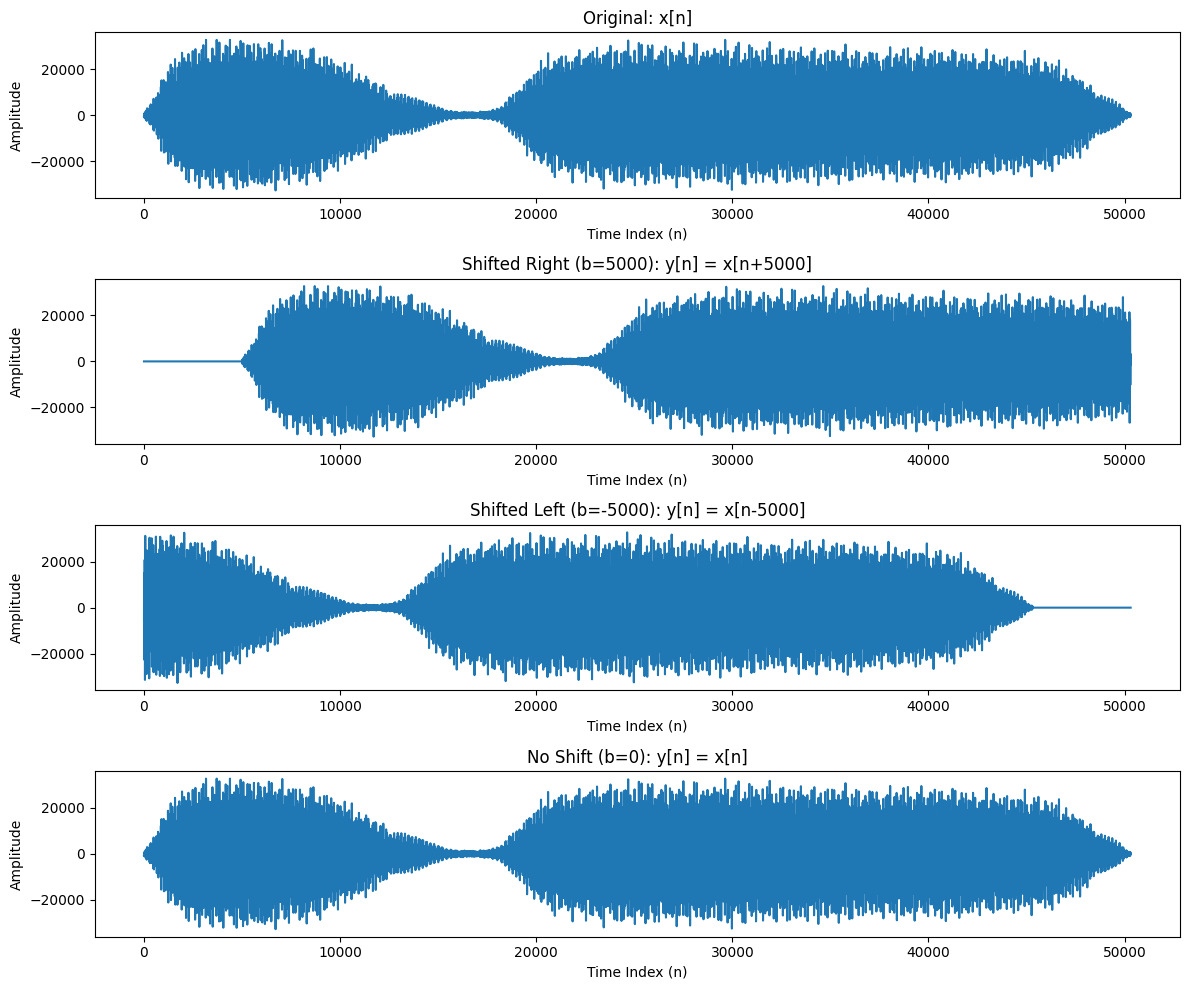

Play original signal:



Play shifted right (b=5000):



Play shifted left (b=-5000):


In [74]:

shift_positive = 5000   # Shift right
shift_negative = -5000  # Shift left
shift_zero = 0          # No shift

shifted_pos = time_shift(train_audio, shift_positive)
shifted_neg = time_shift(train_audio, shift_negative)
shifted_zero = time_shift(train_audio, shift_zero)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Original signal
axes[0].plot(np.arange(len(train_audio)), train_audio)
axes[0].set_title('Original: x[n]')
axes[0].set_xlabel('Time Index (n)')
axes[0].set_ylabel('Amplitude')

# Positive shift
axes[1].plot(np.arange(len(shifted_pos)), shifted_pos)
axes[1].set_title(f'Shifted Right (b={shift_positive}): y[n] = x[n+{shift_positive}]')
axes[1].set_xlabel('Time Index (n)')
axes[1].set_ylabel('Amplitude')

# Negative shift
axes[2].plot(np.arange(len(shifted_neg)), shifted_neg)
axes[2].set_title(f'Shifted Left (b={shift_negative}): y[n] = x[n{shift_negative}]')
axes[2].set_xlabel('Time Index (n)')
axes[2].set_ylabel('Amplitude')

# Zero shift
axes[3].plot(np.arange(len(shifted_zero)), shifted_zero)
axes[3].set_title(f'No Shift (b={shift_zero}): y[n] = x[n]')
axes[3].set_xlabel('Time Index (n)')
axes[3].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

print("Play original signal:")
ipd.display(ipd.Audio(train_audio, rate=fs1))
print(f"\nPlay shifted right (b={shift_positive}):")
ipd.display(ipd.Audio(shifted_pos, rate=fs1))
print(f"\nPlay shifted left (b={shift_negative}):")
ipd.display(ipd.Audio(shifted_neg, rate=fs1))

## Task 3: Volume Variations

In [65]:
# Volume Variation Function Attack, Decay, Sustain and Release (ADSR)
def adsr(note):
    """Generates an ADSR envelope and applies it to a note.

        A: Linear increase to 60% amplitude over 20% length.
        D: Linear decrease to 50% amplitude over 4% length.
        S: Constant 50% amplitude over 40% length.
        R: Linear decrease to 0% amplitude over 36% length.

    Args:
        note: The note to be modified.

    Returns:
        A note that has been scaled by the ADSR envelope.
    """
    n = len(note)
    
    attack_len = int(0.20 * n)   # 20% of note length
    decay_len = int(0.04 * n)    # 4% of note length
    sustain_len = int(0.40 * n)  # 40% of note length
    release_len = n - attack_len - decay_len - sustain_len
    
    # Attack: Linear increase from 0 to 0.6
    attack = np.linspace(0, 0.6, attack_len)
    
    # Decay: Linear decrease from 0.6 to 0.5
    decay = np.linspace(0.6, 0.5, decay_len)
    
    # Sustain: Constant at 0.5
    sustain = np.ones(sustain_len) * 0.5
    
    # Release: Linear decrease from 0.5 to 0
    release = np.linspace(0.5, 0, release_len)
    
    envelope = np.concatenate([attack, decay, sustain, release])
    return note * envelope

In [75]:
# Use your function Apply an ADSR envelope to each note.

score = [
    (A, half),      # A half note
    (A, quarter),   # A quarter note
    (E, quarter),   # E quarter note
    (E, quarter),   # E quarter note
    (E, quarter),   # E quarter note
    (B, quarter),   # B quarter note
    (C, quarter),   # C quarter note
    (B, quarter),   # B quarter note
    (A, whole),     # A whole note
]

notes_adsr = [adsr(note(freq, dur)) for (freq, dur) in score]

rest = np.zeros(int(rest_duration * DEFAULT_SAMPLE_RATE))
notes_with_rest = [np.concatenate([n, rest]) for n in notes_adsr]
song_adsr = np.concatenate(notes_with_rest)

# Play the audio sample
play(song_adsr)

Envelope of song with ADSR:


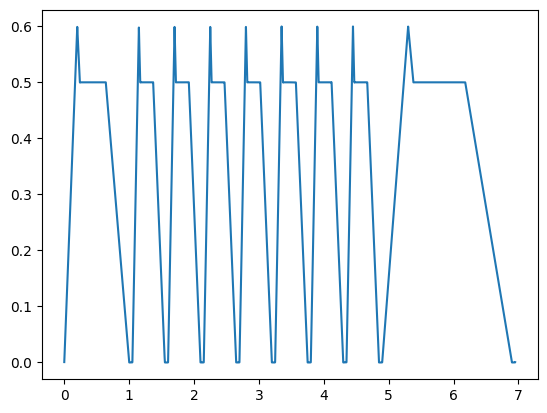

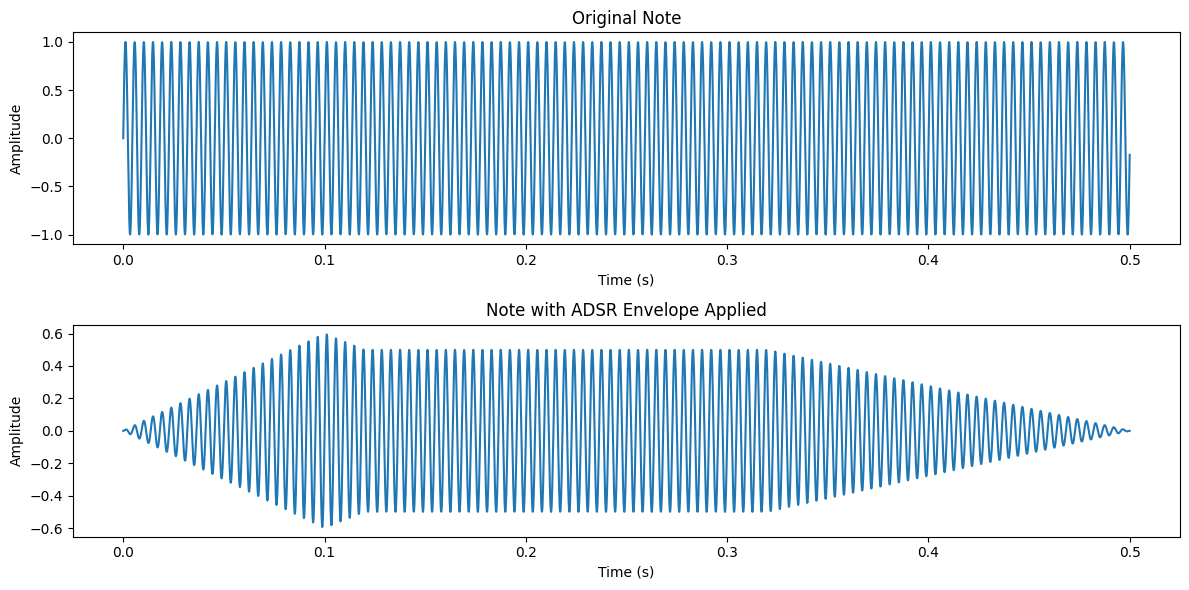

In [82]:
# Display the envelope
print("Envelope of song with ADSR:")
display_envelope(song_adsr)

sample_note = note(A, quarter)
sample_adsr = adsr(sample_note)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Original note
t = np.linspace(0, quarter, len(sample_note))
axes[0].plot(t, sample_note)
axes[0].set_title('Original Note')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Note with ADSR envelope
axes[1].plot(t, sample_adsr)
axes[1].set_title('Note with ADSR Envelope Applied')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

**Supplementary Questions:** Instead of enveloping with the ADSR function, how would you envelope with a decaying exponential?

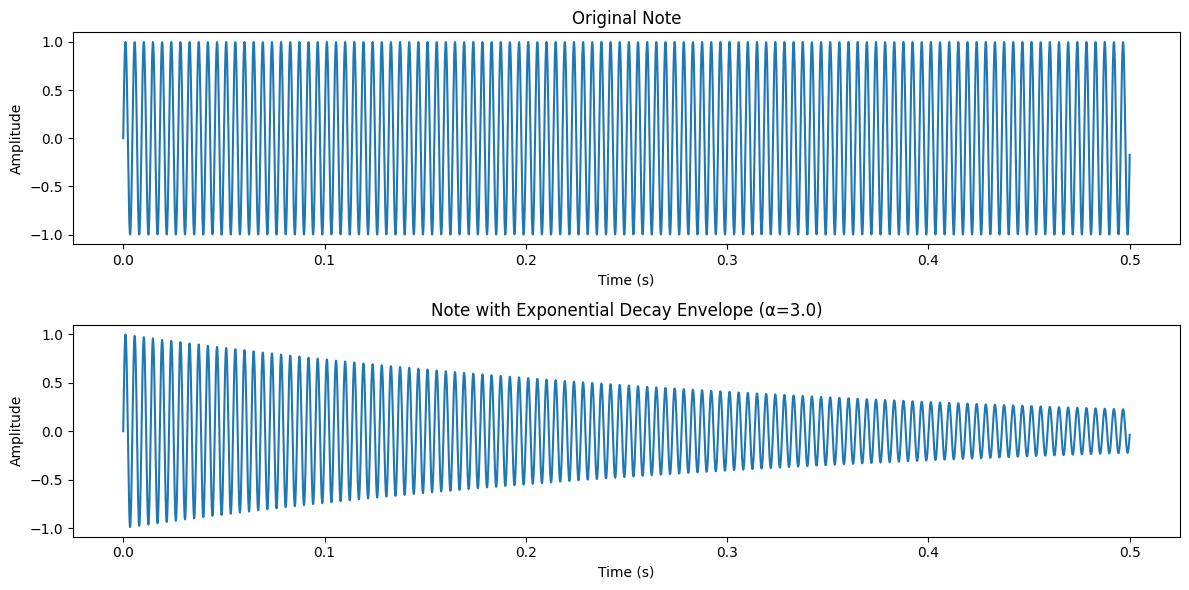

Original note:


Note with exponential envelope:


In [84]:
def exp_envelope(note_signal, alpha=3.0, sample_rate=DEFAULT_SAMPLE_RATE):
    """Applies a decaying exponential envelope to a note.
    
    Args:
        note_signal: The note samples to envelope.
        alpha: Decay rate.
        sample_rate: Sample rate.
    
    Returns:
        The note with exponential envelope applied.
    """
    duration = len(note_signal) / sample_rate
    t = np.linspace(0, duration, len(note_signal))
    envelope = np.exp(-alpha * t)
    return note_signal * envelope

original_note = note(A, quarter)
exp_note = exp_envelope(original_note, alpha=3.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
t = np.linspace(0, quarter, len(original_note))

axes[0].plot(t, original_note)
axes[0].set_title('Original Note')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t, exp_note)
axes[1].set_title('Note with Exponential Decay Envelope (α=3.0)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

print("Original note:")
ipd.display(play(original_note))
print("Note with exponential envelope:")
ipd.display(play(exp_note))

**Consequence of using exponential decay:**

The exponential envelope causes the note to start at full volume and fade continuously toward zero. Unlike ADSR, there is no attack phase, no sustain, and no distinct release. This sounds like instruments that naturally decay exponentially.

## Task 4: Overlapping Notes

In [91]:
def overlap(notes, offset):
    """Joins notes together with overlap between consecutive notes.

    Args:
        notes: An array of notes to be joined.
        offset: The amount of allowable overlap between consecutive notes (in samples).

    Returns: 
        A score made from the input notes.
    """
    if len(notes) == 0:
        return np.array([])
    
    if len(notes) == 1:
        return notes[0]
    
    total_length = len(notes[0])
    for i in range(1, len(notes)):
        total_length += len(notes[i]) - offset
    
    # Pad each note and sum them together
    result = np.zeros(total_length)
    position = 0
    for n in notes:
        padded = np.pad(n, (position, total_length - position - len(n)))
        result += padded
        position += len(n) - offset
    
    return result

Play song with overlapping notes:


Envelope of overlapped song:


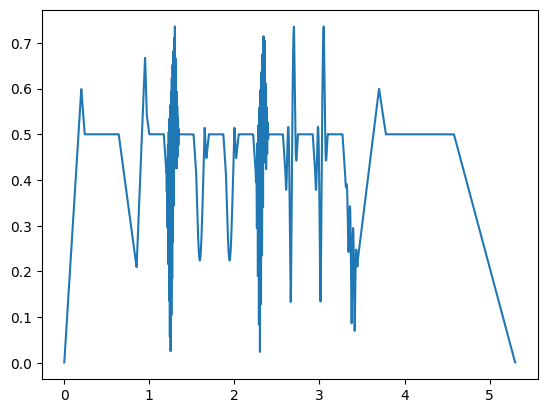

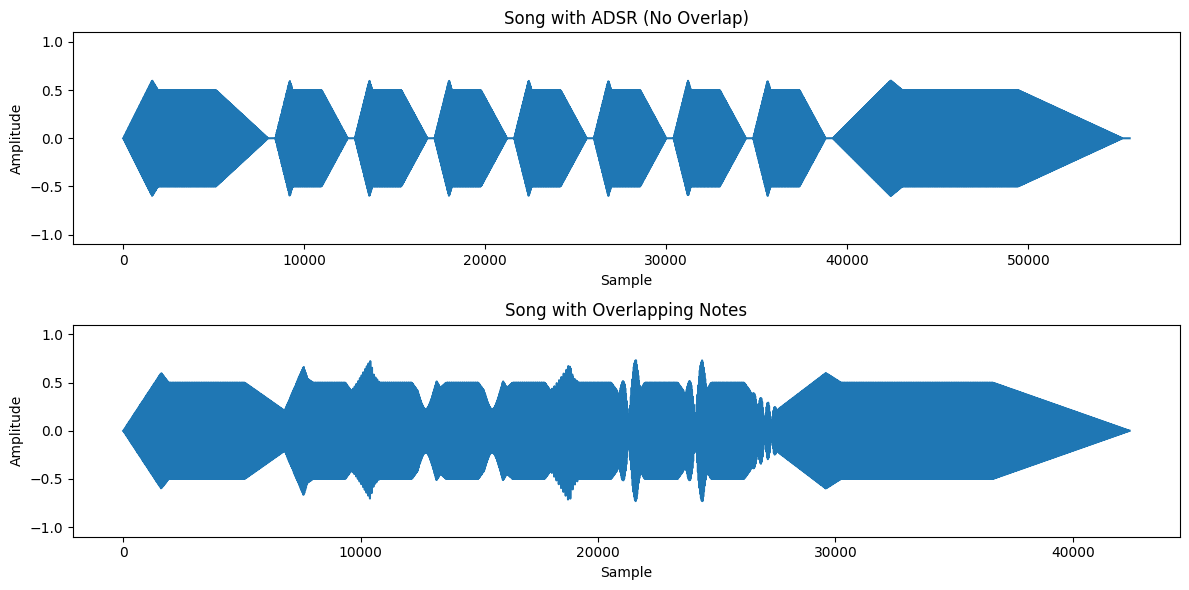

In [100]:
# Smooth the sound by overlapping the notes.

notes_adsr = [adsr(note(freq, dur)) for (freq, dur) in score]

# Using 30% of a quarter note as overlap
overlap_samples = int(0.3 * quarter * DEFAULT_SAMPLE_RATE)

song_overlap = overlap(notes_adsr, overlap_samples)

# Clip to ensure samples stay within ±1.0 range
song_overlap = np.clip(song_overlap, -1.0, 1.0)

# Play the audio sample
print("Play song with overlapping notes:")
ipd.display(play(song_overlap))

# Display the envelope
print("Envelope of overlapped song:")
display_envelope(song_overlap)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Song with ADSR (no overlap)
axes[0].plot(song_adsr)
axes[0].set_title('Song with ADSR (No Overlap)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim([-1.1, 1.1])

# Song with overlap
axes[1].plot(song_overlap)
axes[1].set_title('Song with Overlapping Notes')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Amplitude')
axes[1].set_ylim([-1.1, 1.1])

plt.tight_layout()
plt.show()

### Discussion: Should I use concatenation for overlapping notes?

No, concatenation (`np.concatenate`) places arrays end-to-end sequentially, so each sample belongs to only one note. This creates abrupt transitions between notes.

Using `np.pad`:
1. Pad each note with zeros to match the total song length
2. Position each note at the correct starting point
3. Sum all padded notes together

In overlapping regions, the samples are added, allowing the release of one note to blend smoothly with the attack of the next.